In [2]:
import os, cv2, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from skimage.feature import hog, local_binary_pattern

from sklearn.model_selection import StratifiedKFold, LeaveOneOut
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_curve, auc
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb
from sklearn.base import clone
from sklearn.utils import class_weight

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import albumentations as A

np.random.seed(42)
tf.random.set_seed(42)

BASE_PATH = r"C:\Users\gm733\OneDrive\Desktop\imageparkinson"
IMG_SIZE = (128,128)

In [3]:
def load_all(root, subset):
    X, y = [], []

    for dtype in ['spiral','wave','drawings']:
        path = os.path.join(root, dtype, subset)

        if not os.path.exists(path):
            continue

        for label, cls in enumerate(['healthy','parkinson']):
            class_path = os.path.join(path, cls)

            for f in os.listdir(class_path):
                img = cv2.imread(os.path.join(class_path,f), cv2.IMREAD_GRAYSCALE)
                if img is None:
                    continue

                img = cv2.resize(img, IMG_SIZE)
                X.append(img)
                y.append(label)

    return np.array(X), np.array(y)

X_train_raw, y_train = load_all(BASE_PATH, "training")
X_test_raw,  y_test  = load_all(BASE_PATH, "testing")

print("Train:", X_train_raw.shape)
print("Test :", X_test_raw.shape)

print("Healthy:", np.sum(y_train==0))
print("PD:", np.sum(y_train==1))

total = len(y_train)
print("Healthy %:", np.sum(y_train==0)/total)
print("PD %:", np.sum(y_train==1)/total)

Train: (144, 128, 128)
Test : (60, 128, 128)
Healthy: 72
PD: 72
Healthy %: 0.5
PD %: 0.5


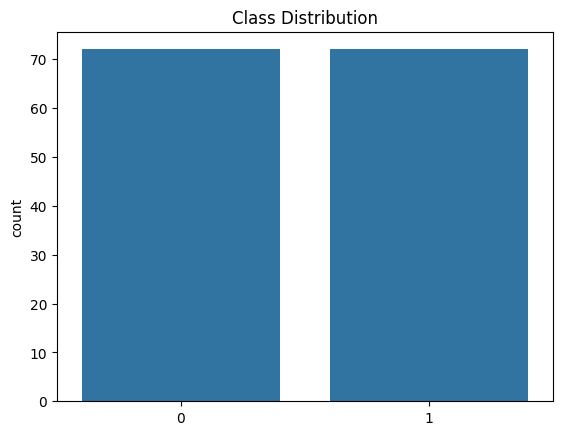

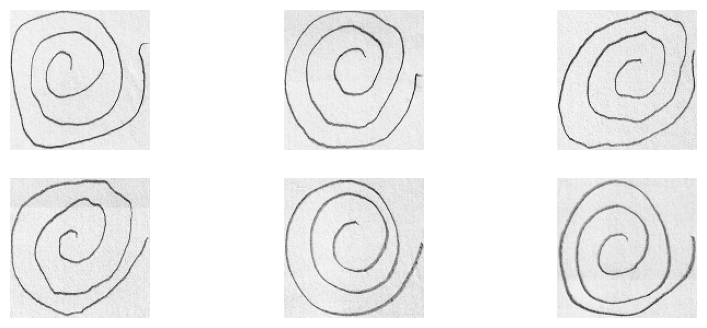

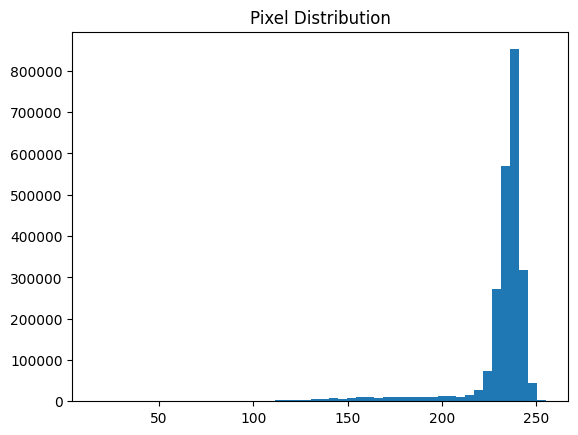

In [4]:
sns.countplot(x=y_train)
plt.title("Class Distribution")
plt.show()

plt.figure(figsize=(10,4))
for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(X_train_raw[i], cmap='gray')
    plt.axis('off')
plt.show()

plt.hist(X_train_raw.flatten(), bins=50)
plt.title("Pixel Distribution")
plt.show()

In [7]:
def extract_features(img):
    hog_feat = hog(img, orientations=9, pixels_per_cell=(8,8),
                   cells_per_block=(2,2), feature_vector=True)

    lbp = local_binary_pattern(img, 8, 1, method='uniform')
    hist,_ = np.histogram(lbp.ravel(), bins=10, range=(0,10))
    hist = hist/(hist.sum()+1e-8)

    edges = cv2.Canny(img,50,150)
    edge_density = np.sum(edges>0)/img.size

    mean_intensity = np.mean(img)
    std_intensity = np.std(img)

    return np.concatenate([hog_feat, hist, [edge_density, mean_intensity, std_intensity]])
X_train_geo = np.array([extract_features(i) for i in X_train_raw])
X_test_geo  = np.array([extract_features(i) for i in X_test_raw])


In [8]:
ml_models = {
    'RF': RandomForestClassifier(n_estimators=200),
    'SVM': SVC(kernel='rbf', C=2, gamma='scale', probability=True),
    'XGB': xgb.XGBClassifier(n_estimators=200, learning_rate=0.05),
    'DT': DecisionTreeClassifier(max_depth=5),
    'NB': GaussianNB(),
    'KNN': KNeighborsClassifier(n_neighbors=3)
}

In [30]:
print("\nML Results\n")

for name, model in ml_models.items():
    loo = LeaveOneOut()
    preds, trues = [], []

    for tr, val in loo.split(X_train_geo, y_train):
        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_train_geo[tr])
        X_val = scaler.transform(X_train_geo[val])

        m = clone(model)
        m.fit(X_tr, y_train[tr])

        preds.extend(m.predict(X_val))
        trues.extend(y_train[val])

    print(name, accuracy_score(trues, preds))


ML Results

RF 0.7361111111111112
SVM 0.7638888888888888
XGB 0.6319444444444444
DT 0.6527777777777778
NB 0.6944444444444444
KNN 0.7708333333333334


In [31]:
aug = A.Compose([
    A.Rotate(limit=15, p=0.6),
    A.HorizontalFlip(p=0.5),
    A.RandomBrightnessContrast(p=0.3),
])
X_aug, y_aug = [], []

for img, lbl in zip(X_train_raw, y_train):
    X_aug.append(img); y_aug.append(lbl)

    for _ in range(2):
        X_aug.append(aug(image=img)['image'])
        y_aug.append(lbl)

X_aug = np.array(X_aug)
y_aug = np.array(y_aug)

In [32]:
X_train_cnn = X_aug/255.0
X_test_cnn  = X_test_raw/255.0

X_train_cnn = np.expand_dims(X_train_cnn,-1)
X_test_cnn  = np.expand_dims(X_test_cnn,-1)

In [33]:
def build_cnn():
    model = models.Sequential([
        layers.Conv2D(32,3,activation='relu',input_shape=(128,128,1)),
        layers.MaxPooling2D(),

        layers.Conv2D(64,3,activation='relu'),
        layers.MaxPooling2D(),

        layers.Conv2D(128,3,activation='relu'),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(128,activation='relu'),
        layers.Dropout(0.4),
        layers.Dense(1,activation='sigmoid')
    ])
    return model

In [35]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for fold,(tr,val) in enumerate(skf.split(X_train_raw,y_train)):
    print("Fold",fold+1)

    X_tr = X_train_cnn[tr]
    X_val = X_train_cnn[val]

    y_tr = y_train[tr]
    y_val = y_train[val]

    model = build_cnn()

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    model.fit(
        X_tr,y_tr,
        validation_data=(X_val,y_val),
        epochs=50,
        batch_size=16,
        

        class_weight=class_weights,
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
            ReduceLROnPlateau(patience=4)
        ],
        verbose=0
    )

    y_prob = model.predict(X_val).flatten()
    y_pred = (y_prob > 0.45).astype(int)

    print("Accuracy:", accuracy_score(y_val,y_pred))

Fold 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
Accuracy: 0.6551724137931034
Fold 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
Accuracy: 0.8275862068965517
Fold 3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
Accuracy: 0.5172413793103449
Fold 4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step
Accuracy: 0.5172413793103449
Fold 5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 100ms/step
Accuracy: 0.7142857142857143


In [36]:
model = build_cnn()

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.fit(
    X_train_cnn, y_aug,
    epochs=50,
    batch_size=16,
    class_weight=class_weights,
    validation_split=0.1,
    callbacks=[
        EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
        ReduceLROnPlateau(patience=4)
    ],
    verbose=0
)

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
Accuracy: 0.5333333333333333
Precision: 0.5172413793103449
Recall: 1.0
F1: 0.6818181818181818


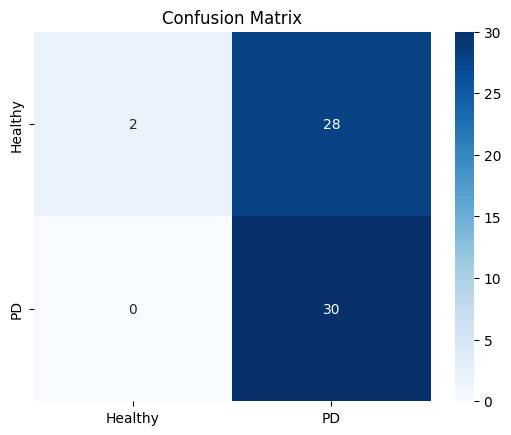

In [37]:
y_prob = model.predict(X_test_cnn).flatten()
y_pred = (y_prob > 0.45).astype(int)

print("Accuracy:", accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall:", recall_score(y_test,y_pred))
print("F1:", f1_score(y_test,y_pred))

cm = confusion_matrix(y_test,y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Healthy','PD'],
            yticklabels=['Healthy','PD'])

plt.title("Confusion Matrix")
plt.show()

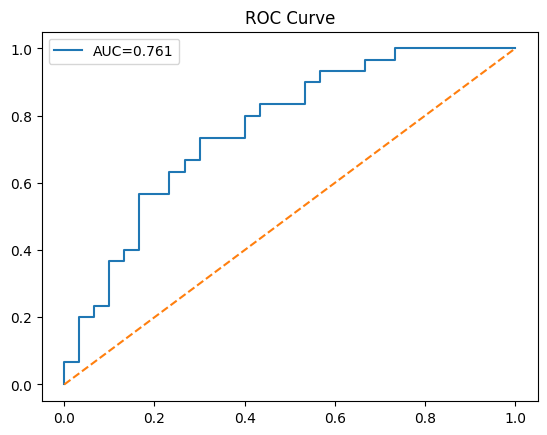

In [38]:
fpr,tpr,_ = roc_curve(y_test,y_prob)
roc_auc = auc(fpr,tpr)

plt.plot(fpr,tpr,label=f"AUC={roc_auc:.3f}")
plt.plot([0,1],[0,1],'--')
plt.legend()
plt.title("ROC Curve")
plt.show()

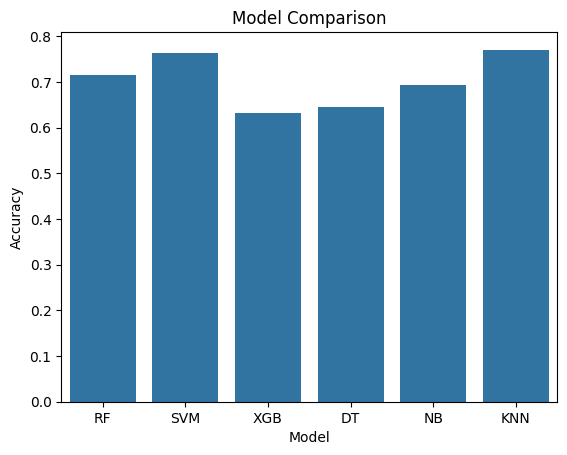

In [41]:
df = pd.DataFrame({
    "Model": list(results_ml.keys()),
    "Accuracy": list(results_ml.values())
})

sns.barplot(x="Model", y="Accuracy", data=df)
plt.title("Model Comparison")
plt.show()

In [40]:
results_ml = {}

for name, model in ml_models.items():
    loo = LeaveOneOut()
    preds, trues = [], []

    for tr, val in loo.split(X_train_geo, y_train):

        scaler = StandardScaler()
        X_tr = scaler.fit_transform(X_train_geo[tr])
        X_val = scaler.transform(X_train_geo[val])

        m = clone(model)
        m.fit(X_tr, y_train[tr])

        preds.extend(m.predict(X_val))
        trues.extend(y_train[val])

    acc = accuracy_score(trues, preds)
    results_ml[name] = acc   # ✅ IMPORTANT
    print(name, acc)

RF 0.7152777777777778
SVM 0.7638888888888888
XGB 0.6319444444444444
DT 0.6458333333333334
NB 0.6944444444444444
KNN 0.7708333333333334


In [9]:
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
import joblib

# Step 1: Scale full training data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train_geo)

# Step 2: Train final model (best model: SVM)
model = SVC(kernel='rbf', C=2, gamma='scale', probability=True)
model.fit(X_scaled, y_train)

# Step 3: Save model and scaler
joblib.dump(model, "model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Model and scaler saved successfully!")

Model and scaler saved successfully!
